In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *
Ag_comp = 0.75

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.11,63
,3000,0,0.42,7
,3000,0,0.45,31
,3000,0,0.11,127


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1026.21    56.72
p_loo      431.96        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1473   99.8%
   (0.70, 1]   (bad)         3    0.2%
   (1, Inf)   (very bad)    0    0.0%



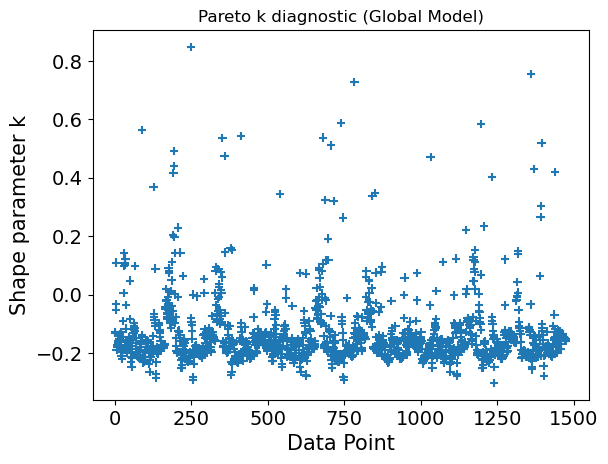

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.062  0.038  -0.103   -0.015      0.019    0.000       6.0     128.0   1.74
deltaG4_0   0.022  0.123  -0.110    0.152      0.061    0.000       6.0     161.0   1.74
deltaG5_0   0.058  0.226  -0.171    0.345      0.111    0.003       6.0     142.0   1.74
Gact2_0     0.522  0.193   0.270    0.714      0.094    0.003       6.0     153.0   1.74
sigma_rel   0.909  0.462   0.418    1.430      0.229    0.001       6.0     161.0   1.73
sigma_base  0.014  0.011   0.000    0.029      0.005    0.000       6.0     129.0   1.73
exponent    1.388  0.667   0.682    2.156      0.331    0.001       6.0     144.0   1.73


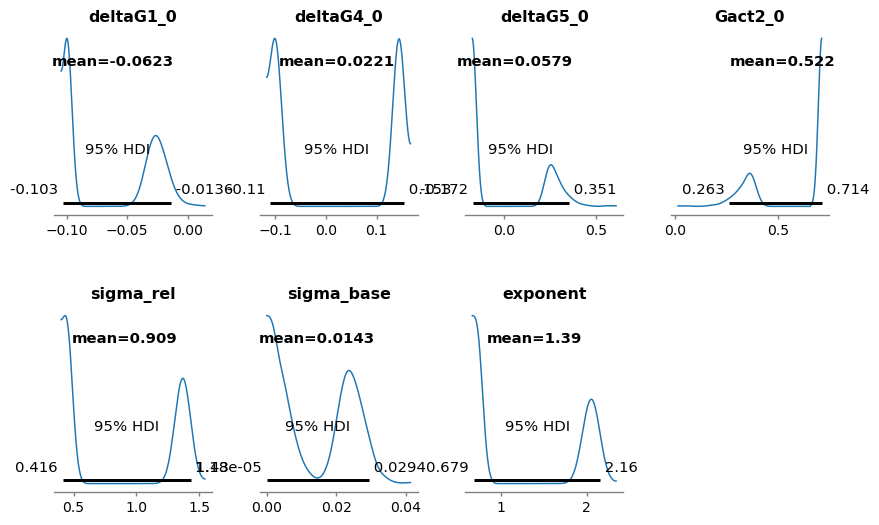

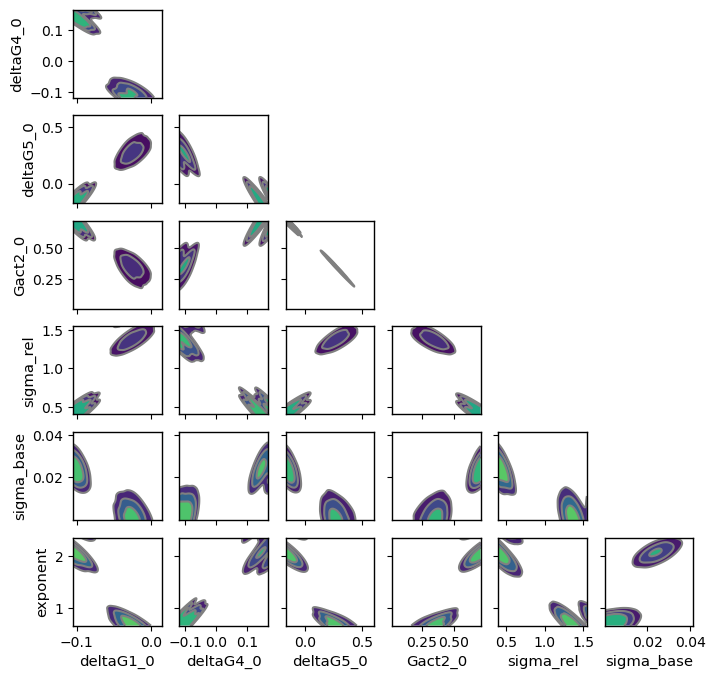

Sampling: [rate]


rate: 0.546


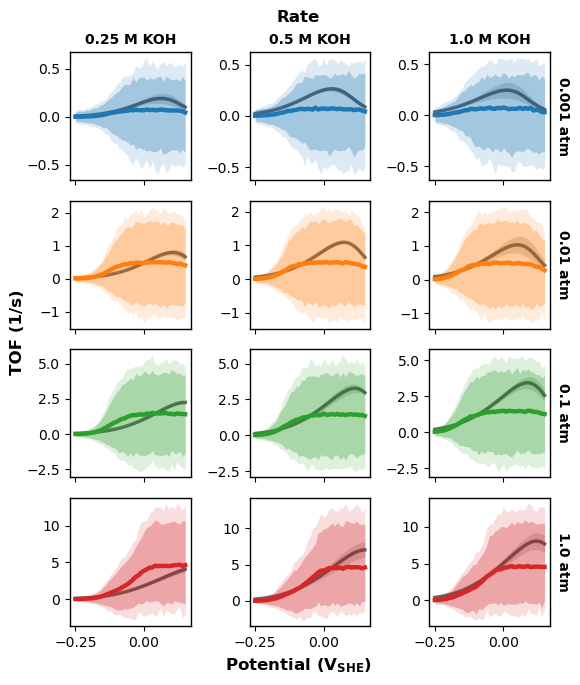

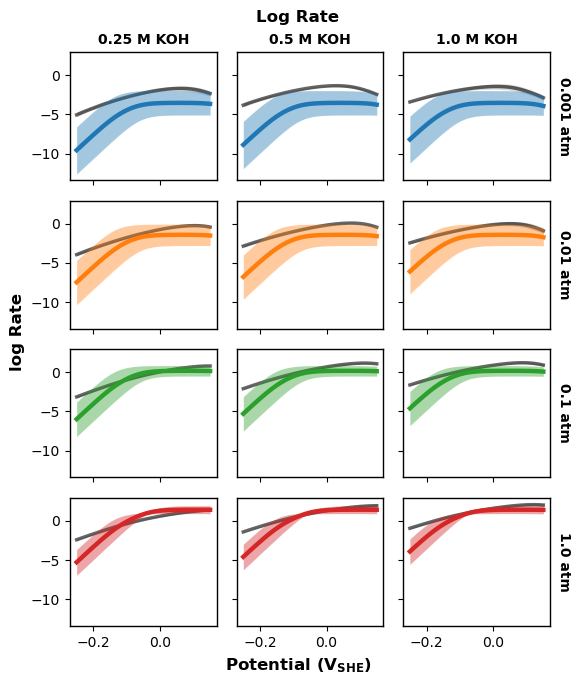

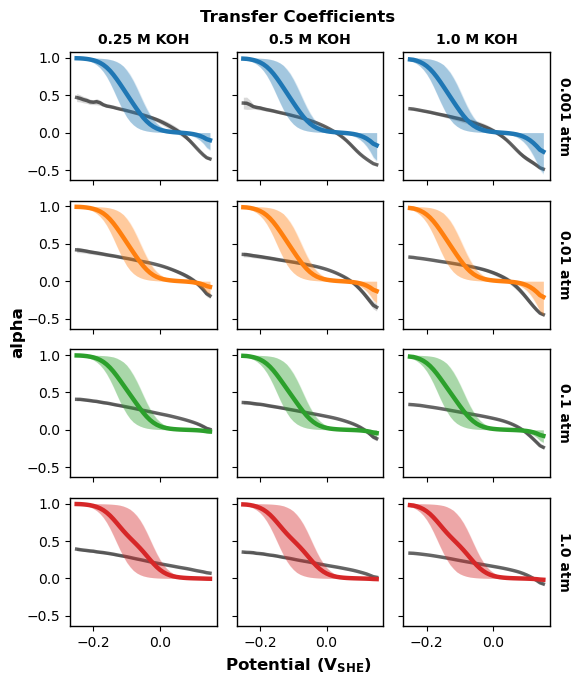

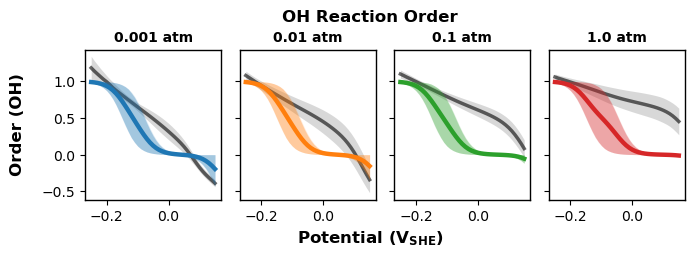

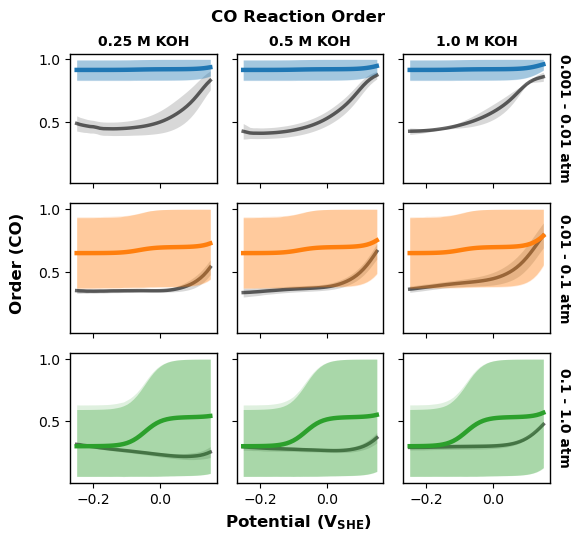

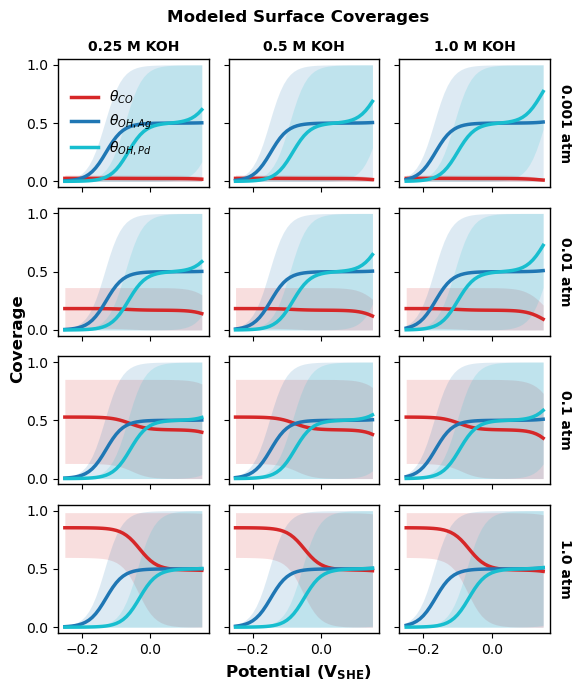

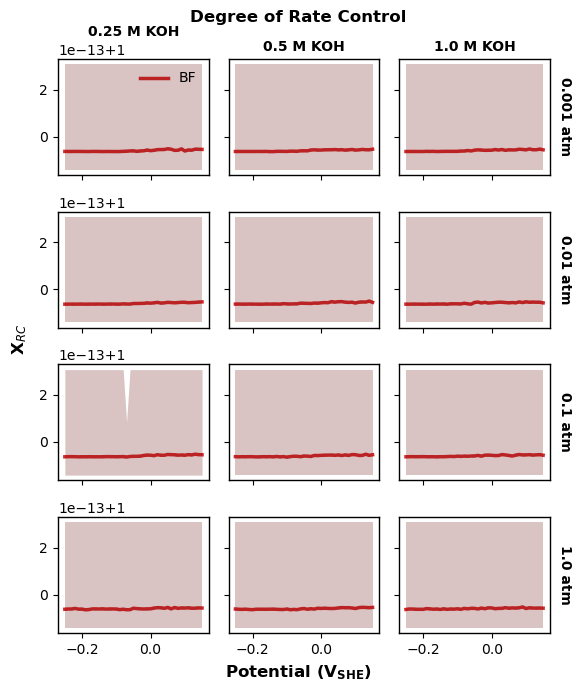

In [3]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)
plot_drc(BF, trace_BF, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.51,31
,3000,0,0.19,15
,3000,0,0.50,7
,3000,0,0.48,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   167.30    56.98
p_loo        9.54        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



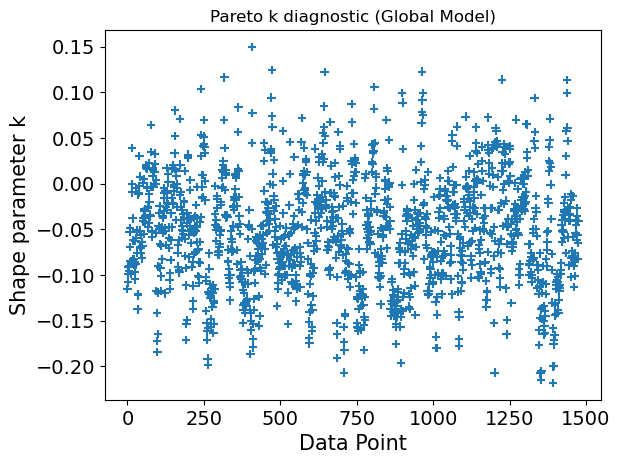

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.101  0.001  -0.104   -0.098      0.000    0.000    1533.0    1962.0    1.0
deltaG4_0   0.067  0.002   0.063    0.071      0.000    0.000    2153.0    2384.0    1.0
deltaG5_0   0.000  0.199  -0.344    0.397      0.003    0.003    3674.0    2675.0    1.0
Gact2_0     0.703  0.001   0.702    0.704      0.000    0.000    1578.0    2050.0    1.0
beta_2      0.246  0.003   0.241    0.252      0.000    0.000    2266.0    2601.0    1.0
sigma_rel   0.249  0.011   0.229    0.269      0.000    0.000    2675.0    2958.0    1.0
sigma_base  0.039  0.003   0.034    0.044      0.000    0.000    2133.0    2297.0    1.0
exponent    2.159  0.077   2.005    2.295      0.002    0.001    2332.0    2685.0    1.0


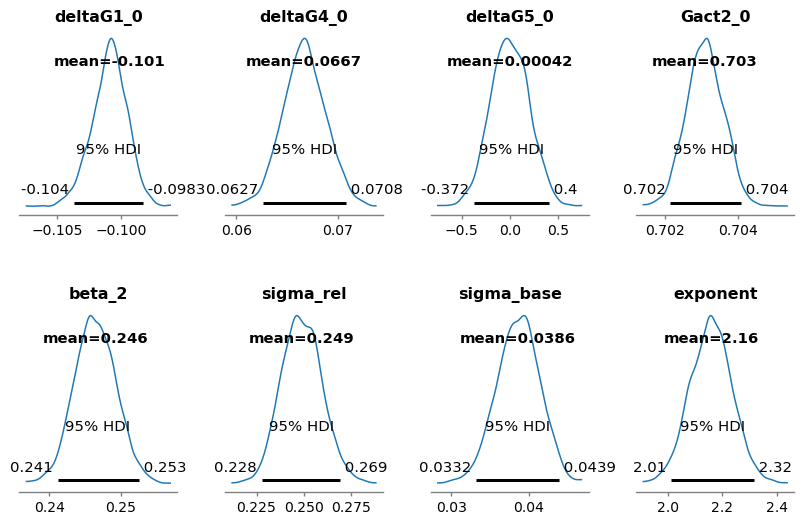

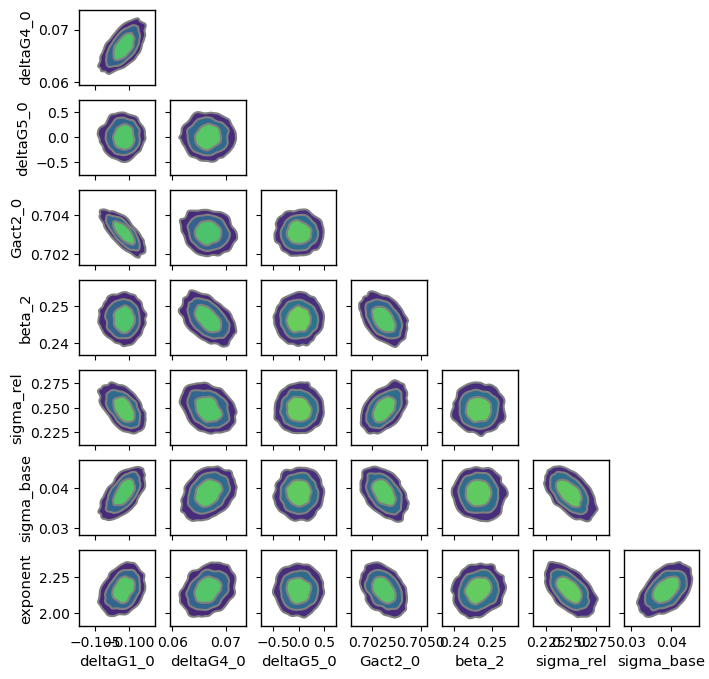

Sampling: [rate]


rate: 0.730


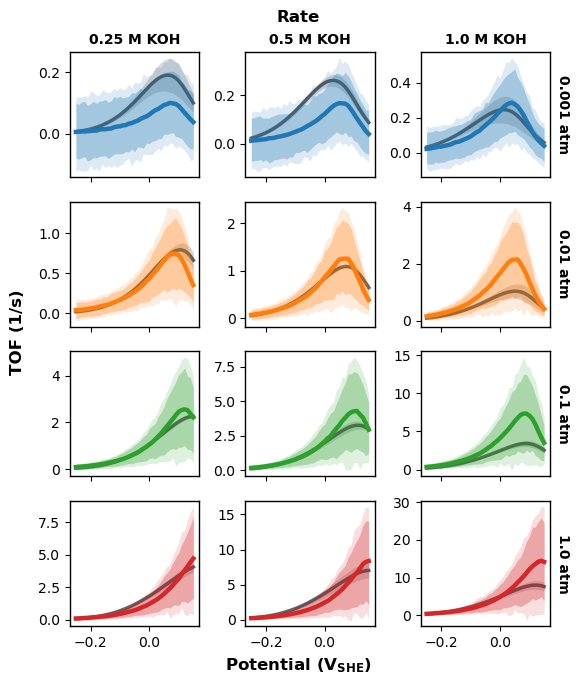

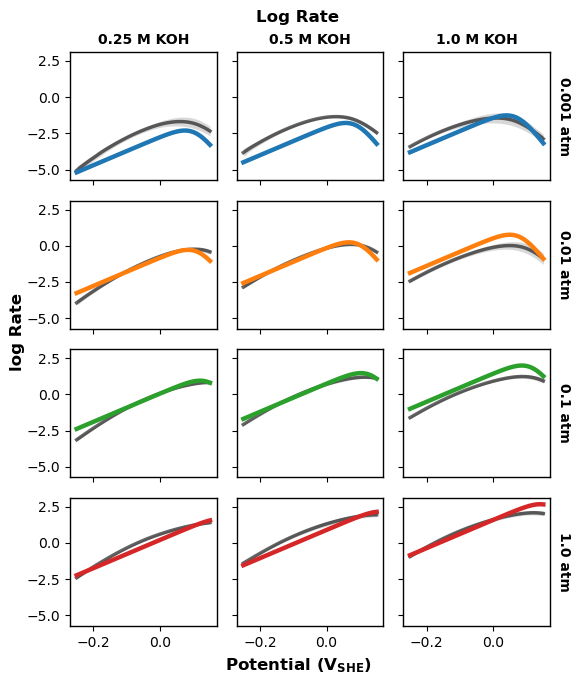

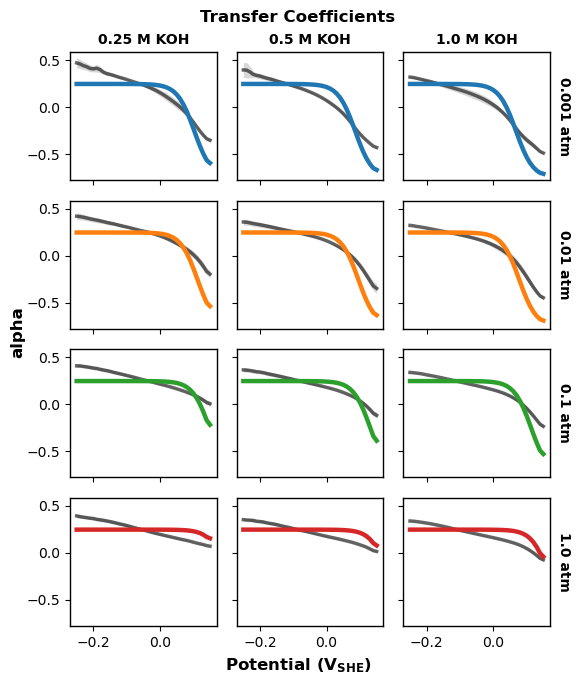

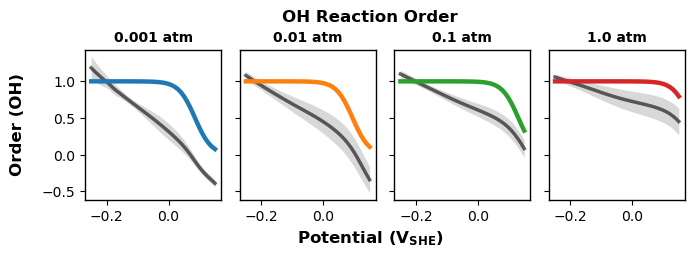

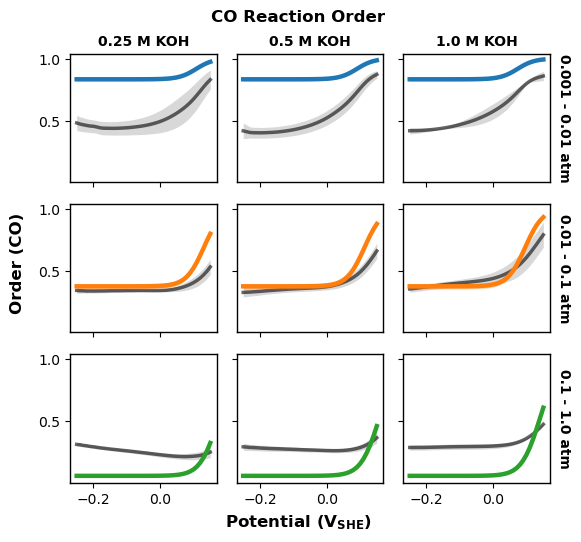

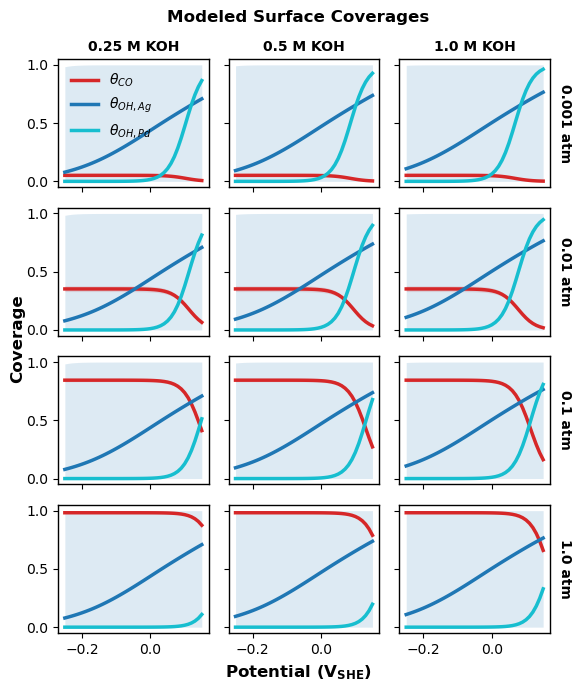

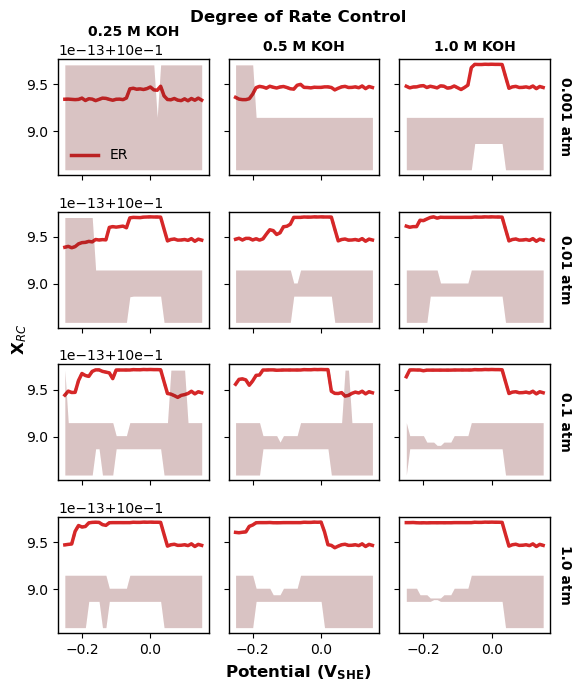

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# BF ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.38,15
,3000,0,0.38,15
,3000,0,0.38,15
,3000,0,0.41,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   361.11    51.46
p_loo       12.07        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



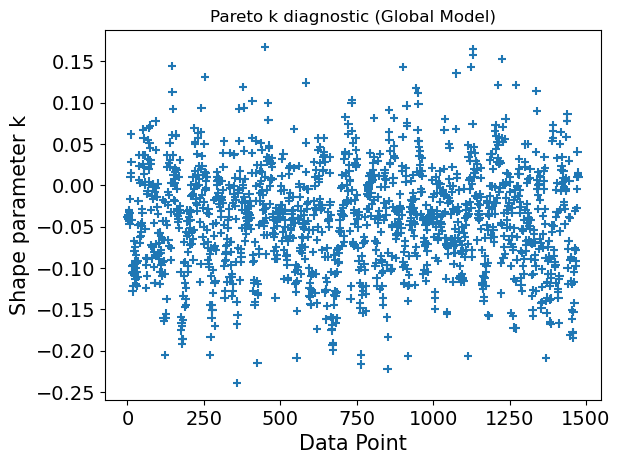

In [6]:
with pm.Model() as BF_ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_2, loo_BF_ER_2 = fit_and_evaluate(BF_ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.092  0.001  -0.094   -0.090      0.000    0.000    2424.0    2731.0    1.0
deltaG4_0   0.096  0.003   0.092    0.101      0.000    0.000    1799.0    2484.0    1.0
deltaG5_0  -0.108  0.005  -0.117   -0.099      0.000    0.000    1855.0    2225.0    1.0
Gact2_BF_0  0.735  0.002   0.731    0.738      0.000    0.000    1376.0    2250.0    1.0
Gact2_ER_0  0.713  0.001   0.711    0.714      0.000    0.000    1686.0    2202.0    1.0
beta_2      0.211  0.005   0.202    0.220      0.000    0.000    1451.0    2215.0    1.0
sigma_rel   0.195  0.009   0.179    0.212      0.000    0.000    3181.0    3115.0    1.0
sigma_base  0.044  0.002   0.040    0.049      0.000    0.000    3420.0    3337.0    1.0
exponent    2.161  0.096   1.978    2.337      0.002    0.002    3188.0    2794.0    1.0


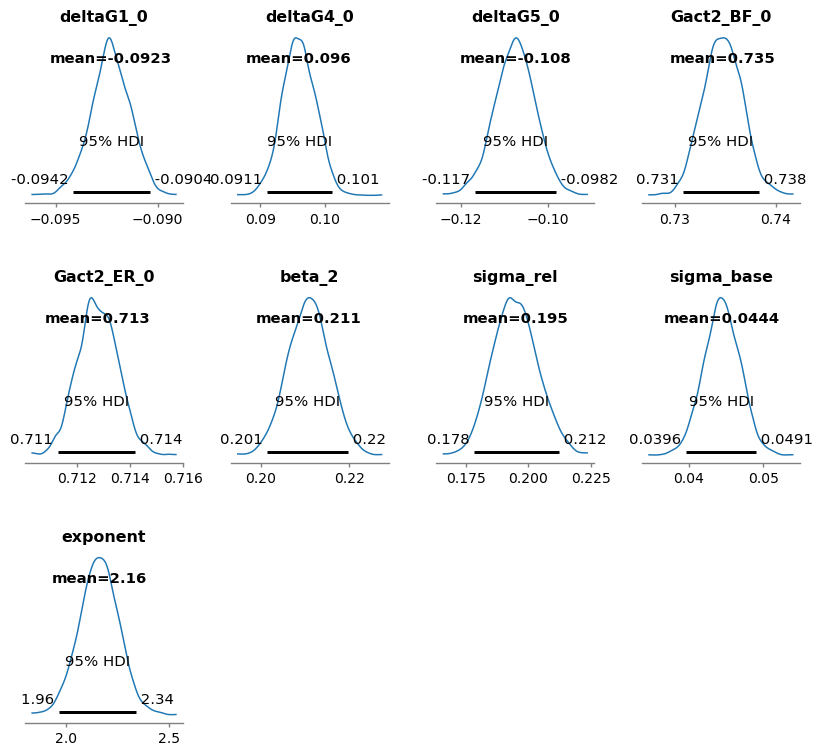

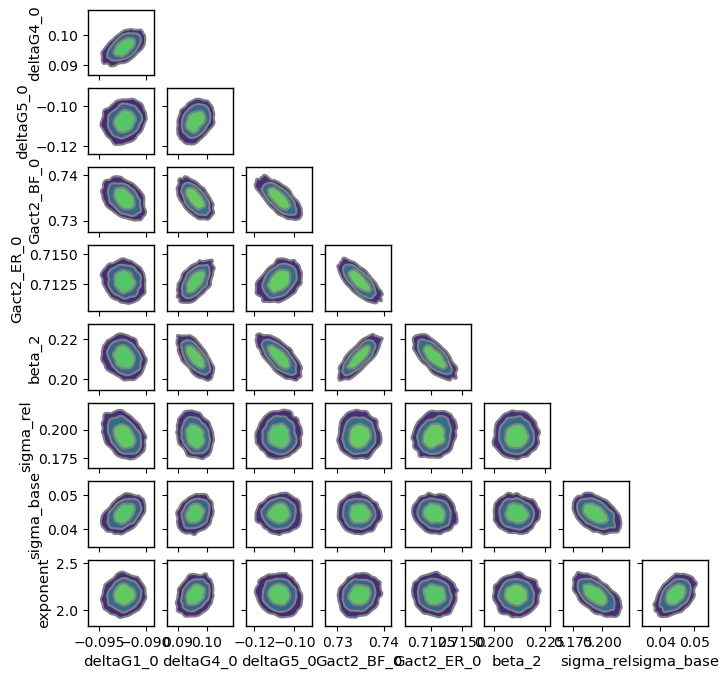

Sampling: [rate]


rate: 0.795


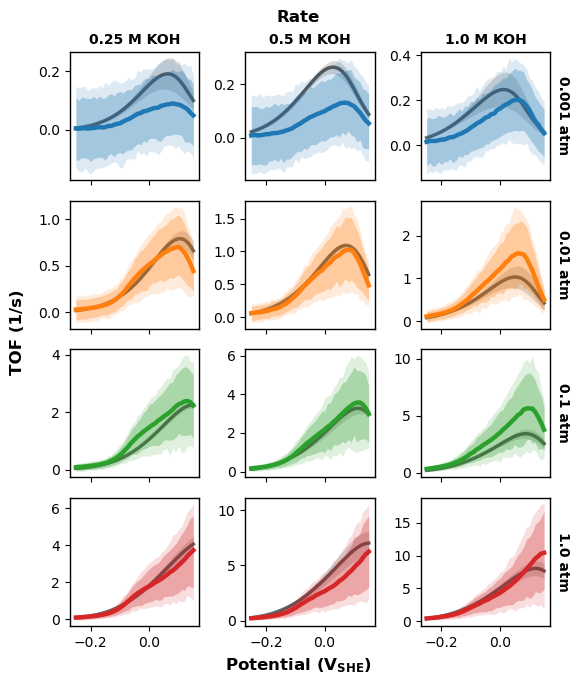

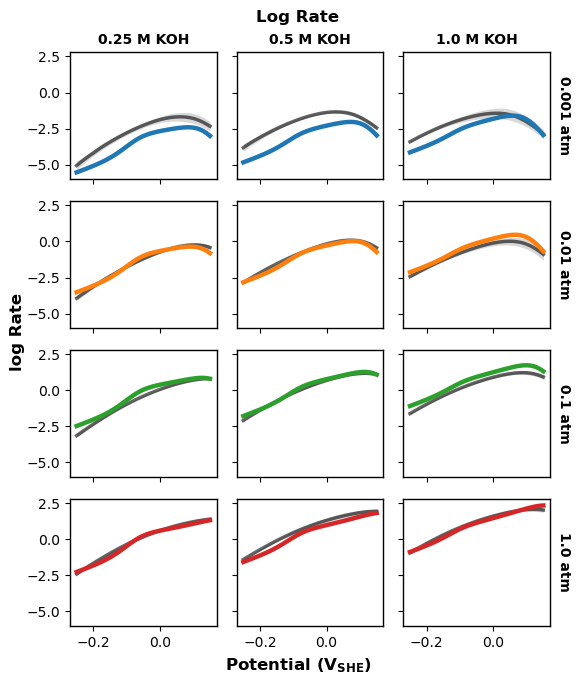

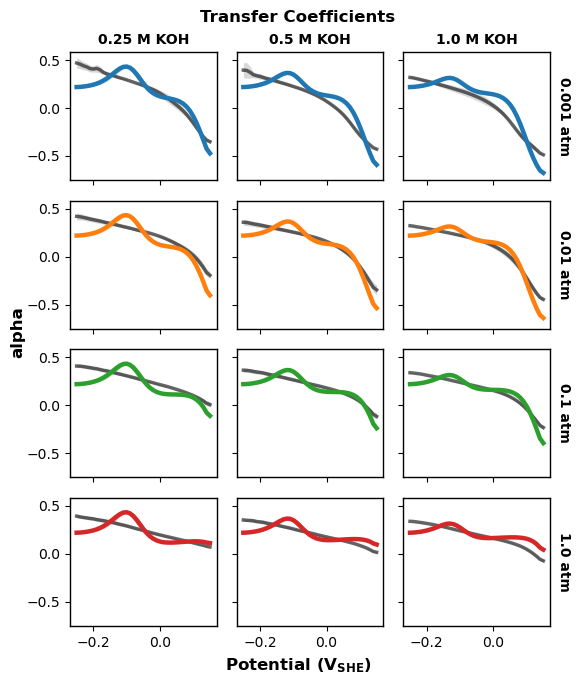

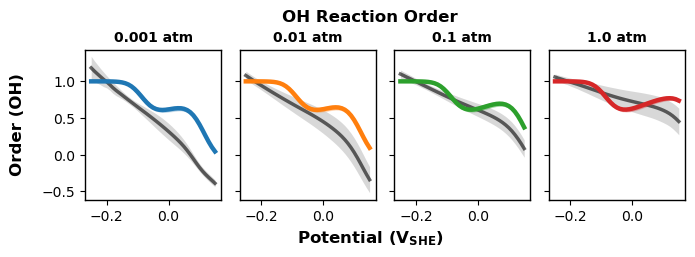

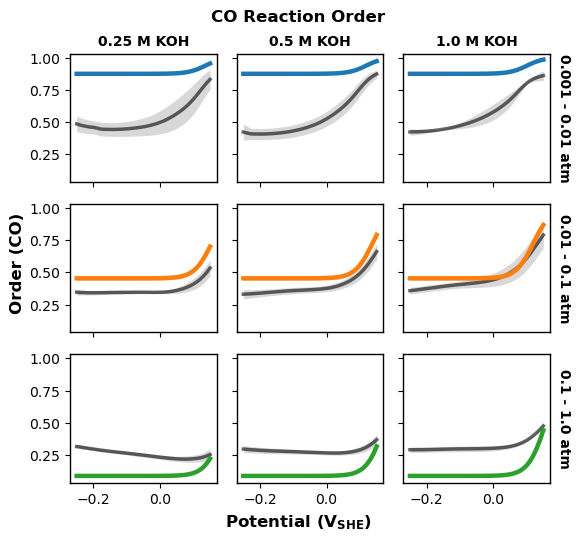

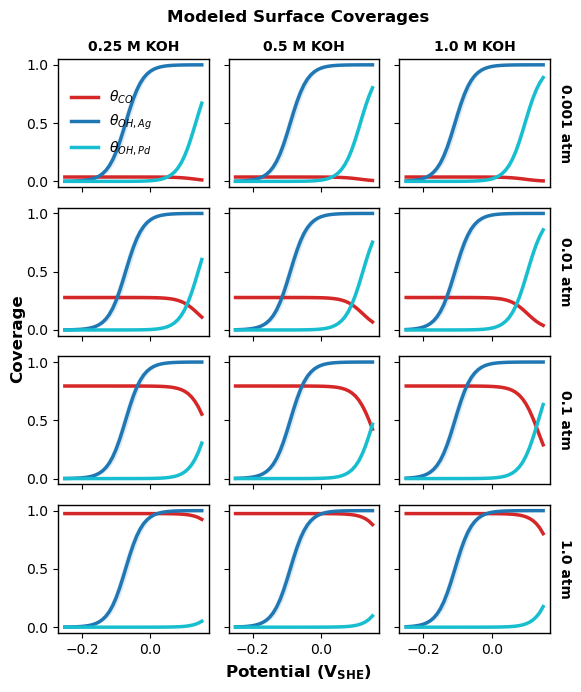

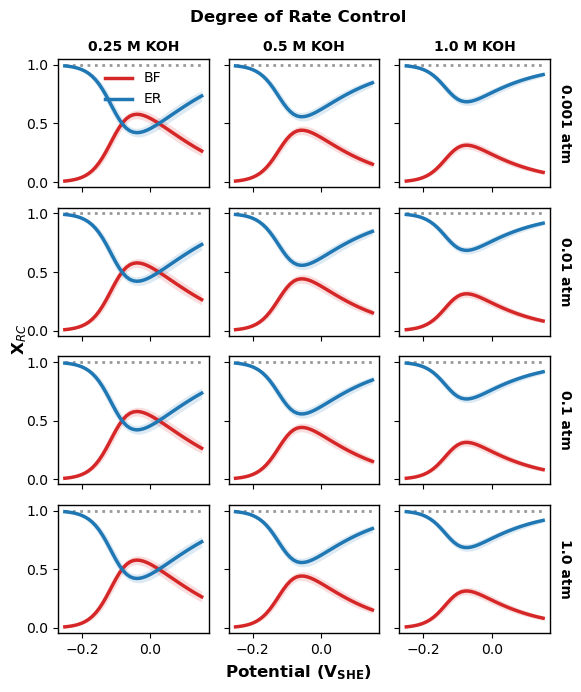

In [7]:
ppc_BF_ER_2 = plot_posteriors(trace_BF_ER_2, BF_ER_2)
plot_model_fits(trace_BF_ER_2, ppc_BF_ER_2); plot_coverages(trace_BF_ER_2)
plot_drc(BF_ER_2, trace_BF_ER_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.35,15
,3000,0,0.39,23
,3000,0,0.41,15
,3000,0,0.43,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   394.42    51.17
p_loo       12.51        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



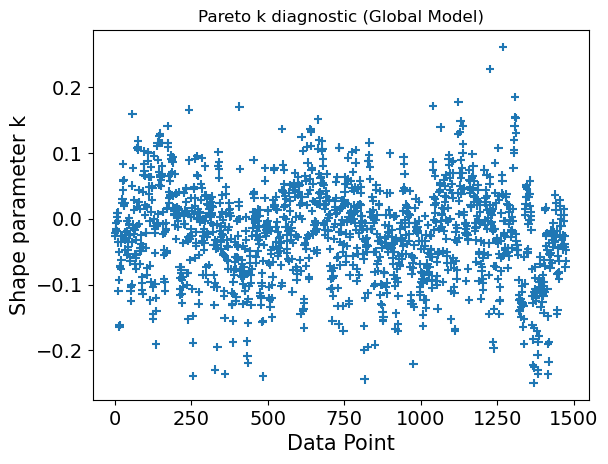

In [8]:
with pm.Model() as BF_ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH_2, loo_BF_ER_LH_2 = fit_and_evaluate(BF_ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.091  0.001  -0.092   -0.089      0.000    0.000    2898.0    2943.0    1.0
deltaG4_0   0.082  0.002   0.078    0.087      0.000    0.000    2654.0    3168.0    1.0
deltaG5_0  -0.114  0.004  -0.122   -0.106      0.000    0.000    2264.0    2544.0    1.0
Gact2_BF_0  0.736  0.002   0.733    0.739      0.000    0.000    1588.0    2029.0    1.0
Gact2_ER_0  0.713  0.001   0.712    0.714      0.000    0.000    2193.0    2265.0    1.0
Gact2_LH_0  0.670  0.003   0.664    0.675      0.000    0.000    3004.0    2898.0    1.0
beta_2      0.208  0.004   0.200    0.216      0.000    0.000    1791.0    2540.0    1.0
sigma_rel   0.184  0.008   0.168    0.199      0.000    0.000    3964.0    3146.0    1.0
sigma_base  0.046  0.002   0.042    0.050      0.000    0.000    4508.0    3466.0    1.0
exponent    2.249  0.096   2.075    2.434      0.001    0.001    4198.0    2586.0    1.0


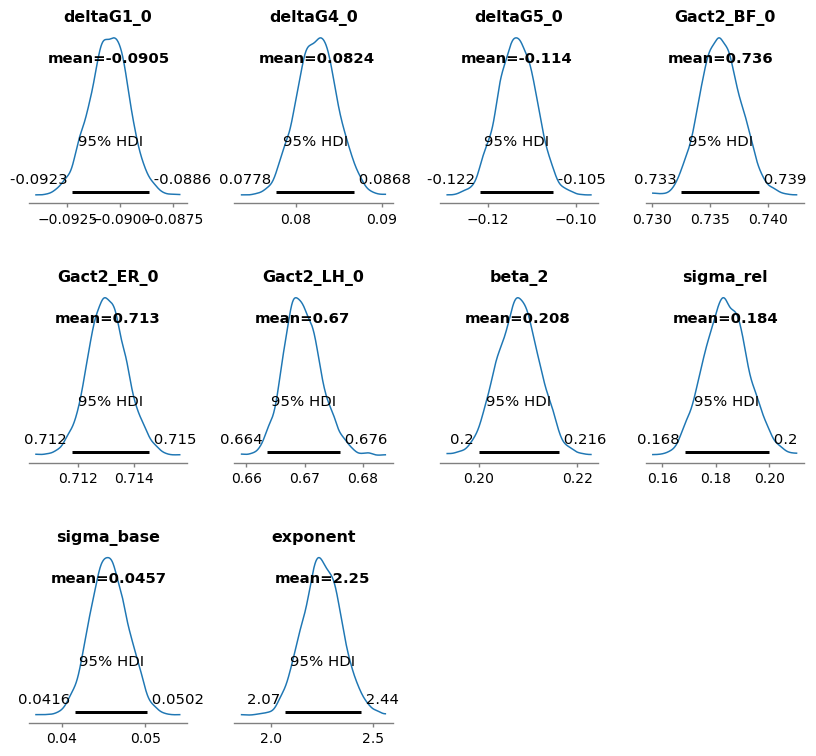

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


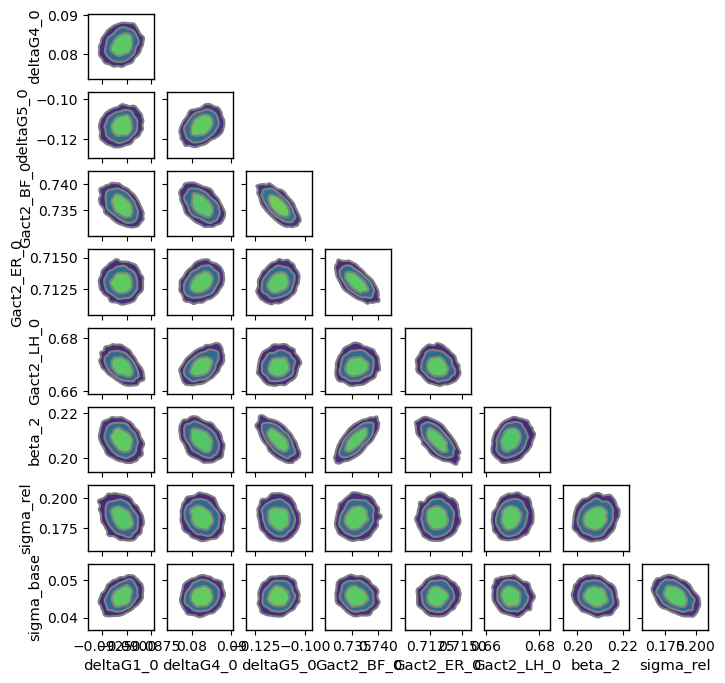

Sampling: [rate]


rate: 0.795


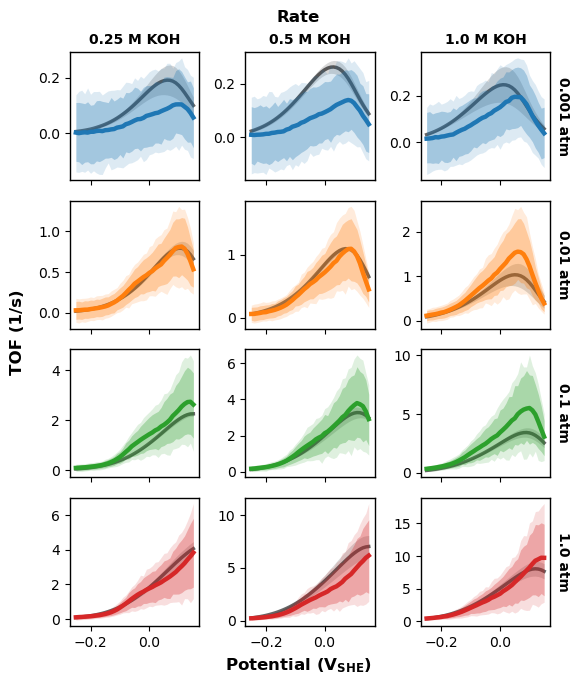

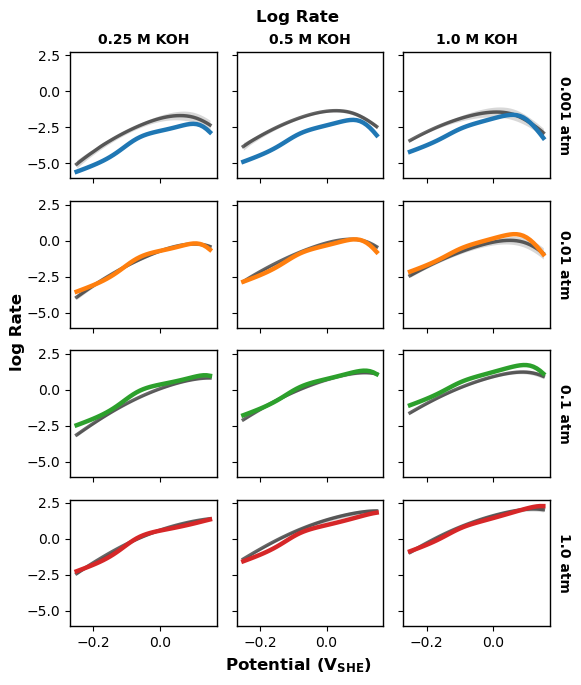

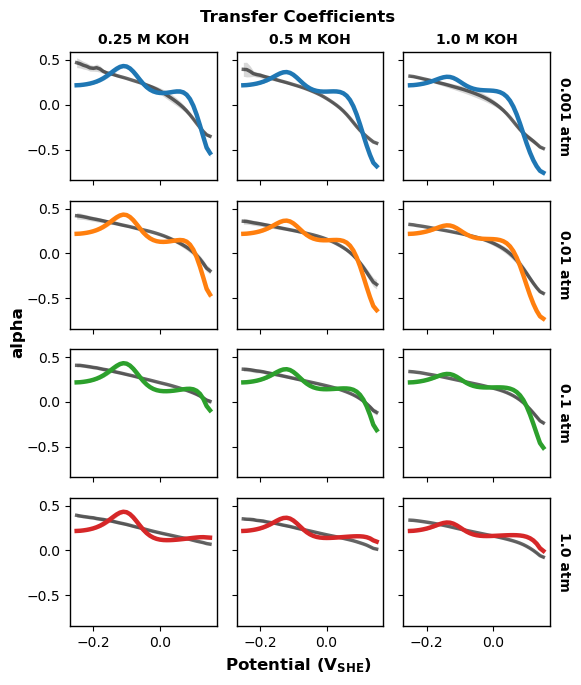

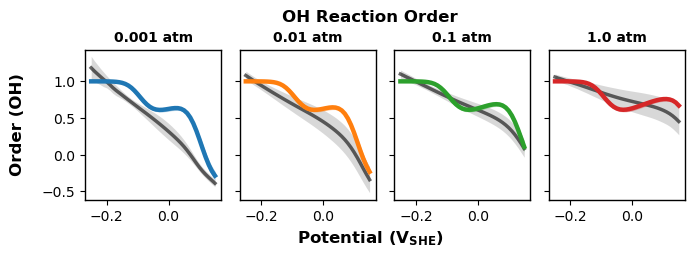

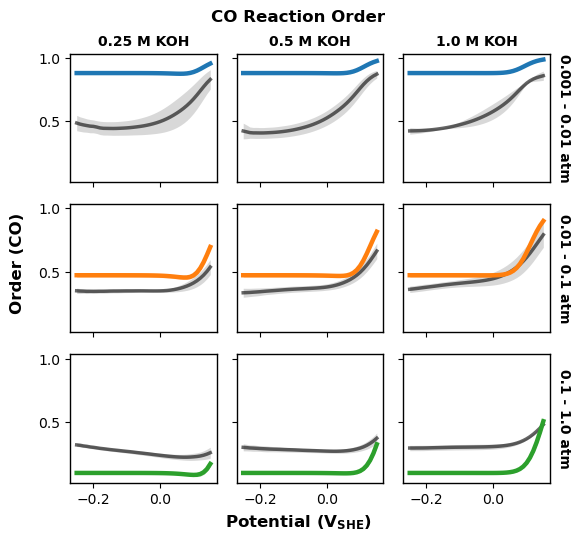

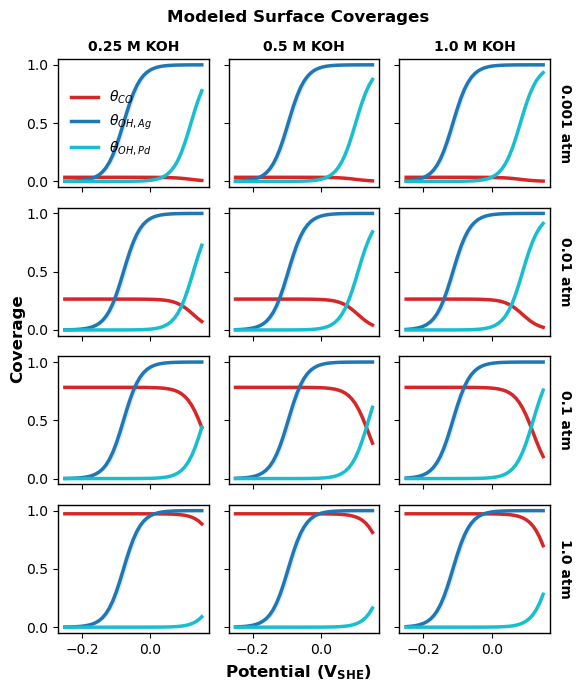

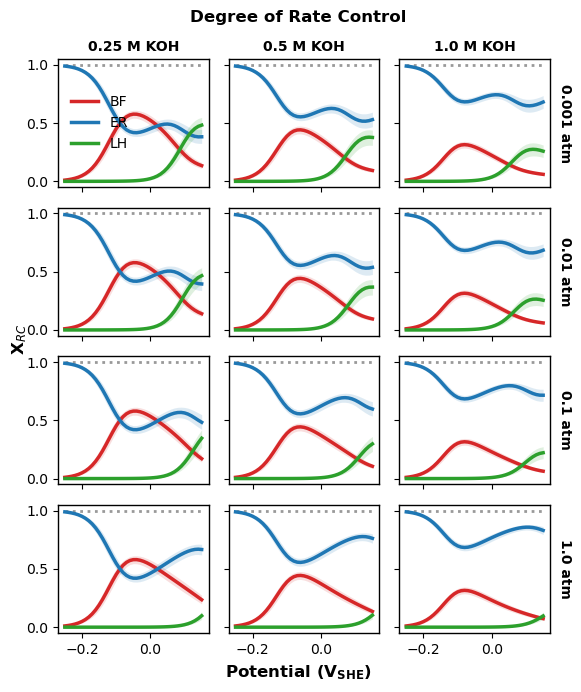

In [9]:
ppc_BF_ER_LH_2 = plot_posteriors(trace_BF_ER_LH_2, BF_ER_LH_2)
plot_model_fits(trace_BF_ER_LH_2, ppc_BF_ER_LH_2); plot_coverages(trace_BF_ER_LH_2)
plot_drc(BF_ER_LH_2, trace_BF_ER_LH_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# Comparison

            rank     elpd_loo       p_loo    elpd_diff        weight         se        dse  warning scale
BF_ER_LH_2     0   394.421356   12.512697     0.000000  8.953563e-01  51.169780   0.000000    False   log
BF_ER_2        1   361.110209   12.065690    33.311147  2.480007e-08  51.461807   6.816804    False   log
ER_2           2   167.295645    9.541311   227.125712  1.046437e-01  56.984389  24.584306    False   log
BF             3 -1026.209847  431.959371  1420.631203  0.000000e+00  56.715704  37.606409     True   log


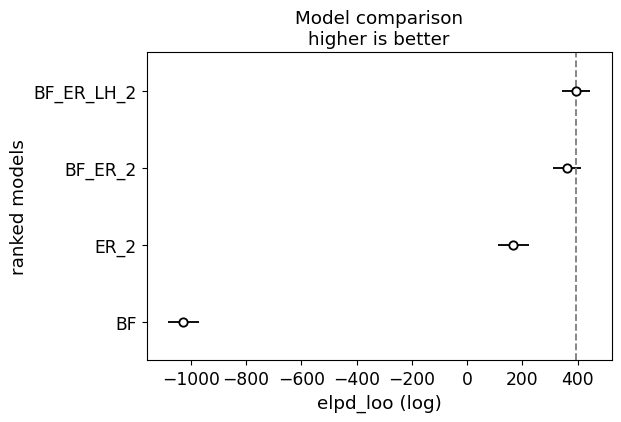

In [10]:
comparison_dict = {
    "BF": loo_BF,
    "ER_2": loo_ER_2,
    "BF_ER_2": loo_BF_ER_2,
    "BF_ER_LH_2": loo_BF_ER_LH_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()